In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold,KFold,cross_val_score
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, mean_absolute_error
from sklearn.metrics import mean_squared_error,r2_score, roc_auc_score,average_precision_score, brier_score_loss
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import shap
import warnings
warnings.filterwarnings("ignore")

# Dataset overview

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Learning/ML/Data/campus_placement_data.csv")
df.head()

,student_id,gender,age,city_tier,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_stream,degree_percentage,...,technical_skills_score,soft_skills_score,aptitude_score,communication_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,placed,salary_lpa
0,STU000001,Male,22,Tier 1,71.01,State,76.76,CBSE,Commerce,64.44,...,6.8,7.8,62.1,6.2,14,1,10,0,1,12.24
1,STU000002,Female,22,Tier 2,58.46,CBSE,57.62,State,Science,68.24,...,4.6,4.8,58.7,7.2,5,1,4,0,1,10.09
2,STU000003,Female,21,Tier 1,67.83,CBSE,65.67,State,Commerce,52.33,...,4.7,5.0,58.9,5.0,30,2,1,0,1,14.94
3,STU000004,Female,21,Tier 2,80.40,CBSE,77.15,State,Science,56.55,...,6.8,7.6,35.0,8.3,31,0,5,0,1,15.49
4,STU000005,Male,21,Tier 1,66.10,State,62.81,ICSE,Science,78.93,...,7.0,5.7,54.0,5.4,24,0,2,0,1,15.13


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   student_id                  100000 non-null  object 
 1   gender                      100000 non-null  object 
 2   age                         100000 non-null  int64  
 3   city_tier                   100000 non-null  object 
 4   ssc_percentage              100000 non-null  float64
 5   ssc_board                   100000 non-null  object 
 6   hsc_percentage              100000 non-null  float64
 7   hsc_board                   100000 non-null  object 
 8   hsc_stream                  100000 non-null  object 
 9   degree_percentage           100000 non-null  float64
 10  degree_field                100000 non-null  object 
 11  mba_percentage              100000 non-null  float64
 12  specialization              35035 non-null   object 
 13  internships_cou

# Exploratory Data Analysis

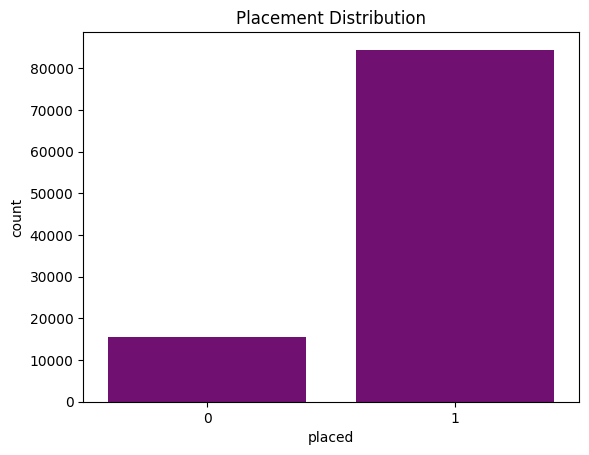

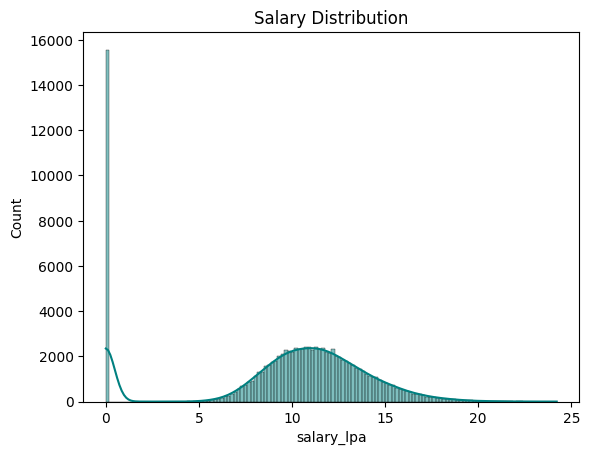

In [ ]:
def target_analysis(df):
  plt.figure()
  sns.countplot(x="placed",data=df,color="purple")
  plt.title("Placement Distribution")
  plt.show()
  plt.figure()
  sns.histplot(df["salary_lpa"],kde=True,color="teal")
  plt.title("Salary Distribution")
  plt.show()
target_analysis(df)

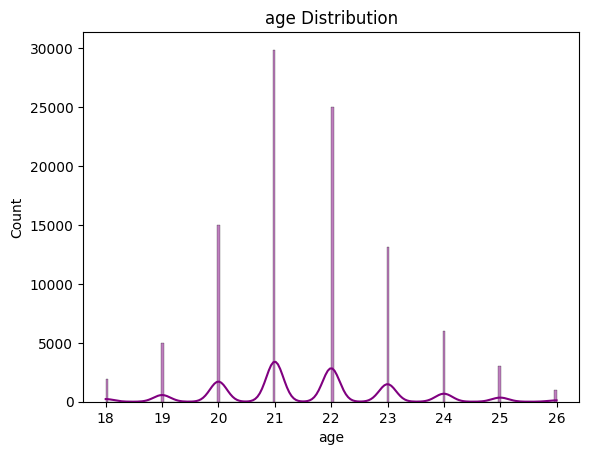

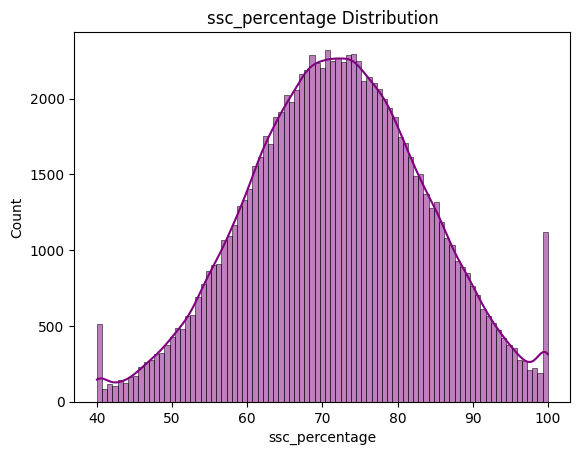

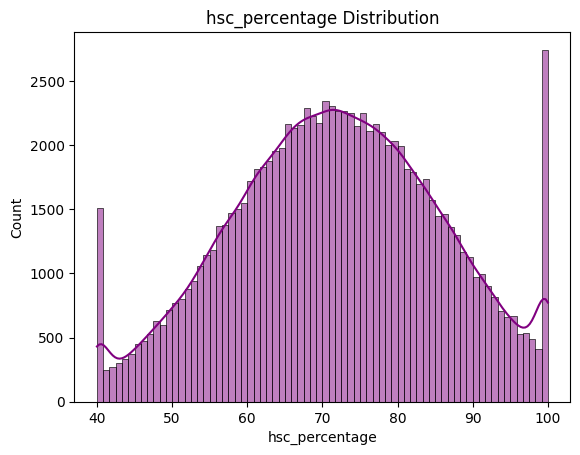

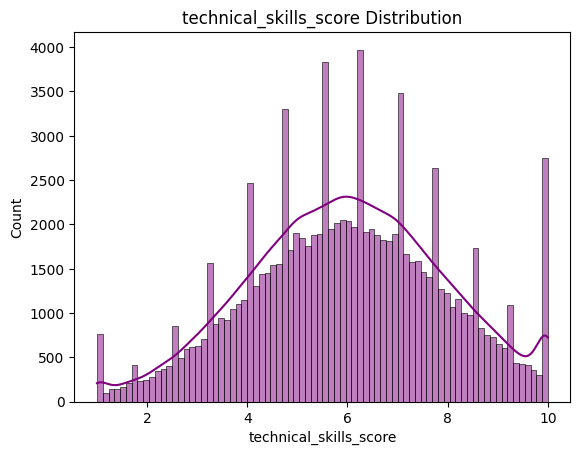

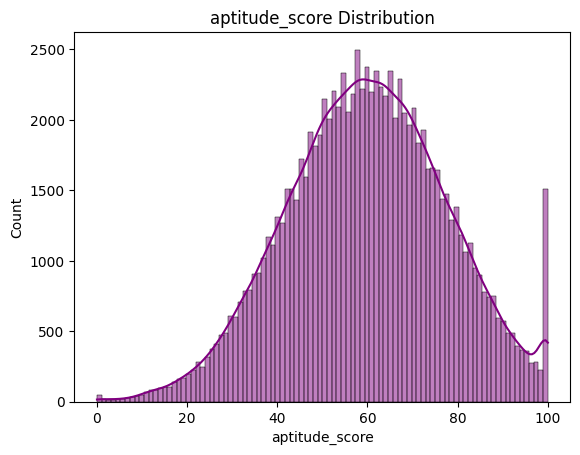

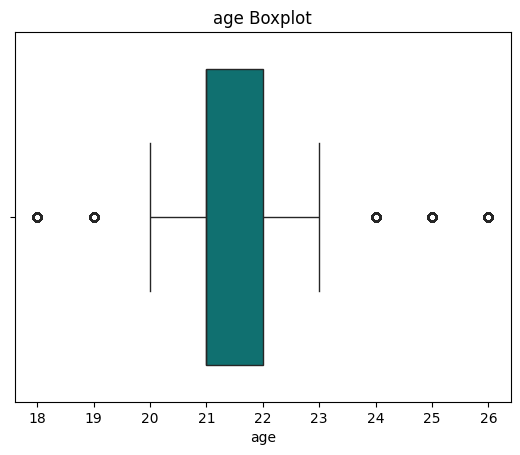

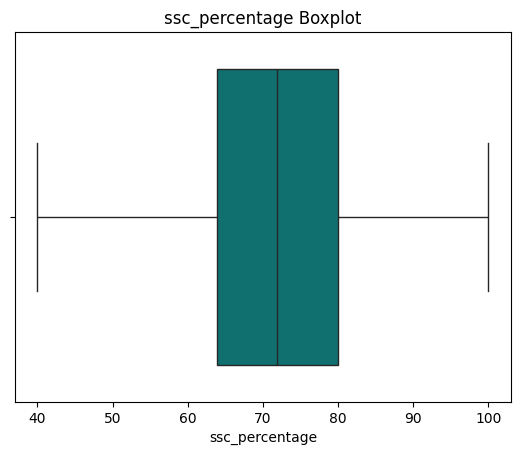

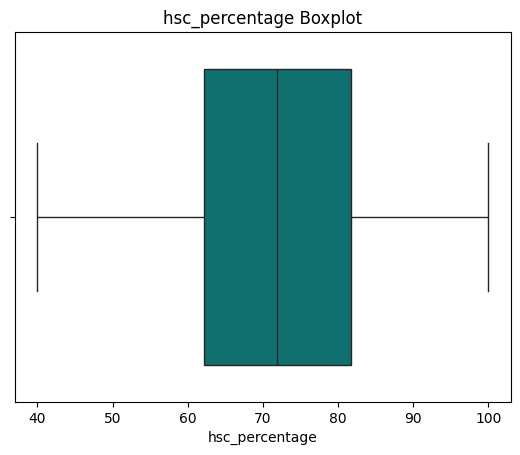

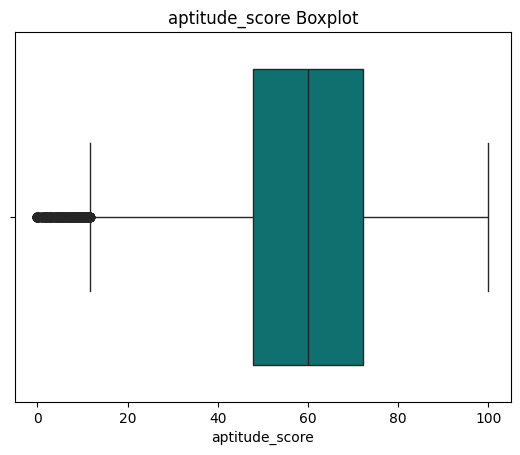

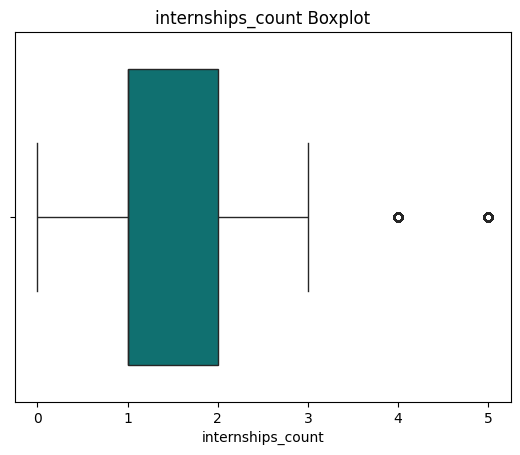

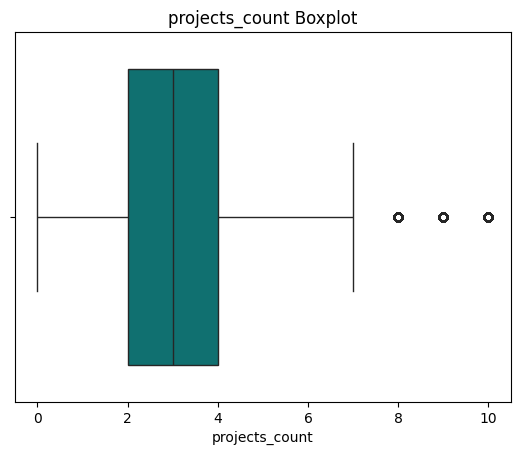

In [ ]:
def numeric_histplot(df):
  num_cols=["age","ssc_percentage","hsc_percentage","technical_skills_score","aptitude_score"]
  for col in num_cols:
    plt.figure()
    sns.histplot(df[col],kde=True,color="purple")
    plt.title(f"{col} Distribution")
    plt.show()
def numeric_boxplot(df):
  num_cols=["age","ssc_percentage","hsc_percentage","aptitude_score","internships_count","projects_count"]
  for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col],color="teal")
    plt.title(f"{col} Boxplot")
    plt.show()
numeric_histplot(df)
numeric_boxplot(df)

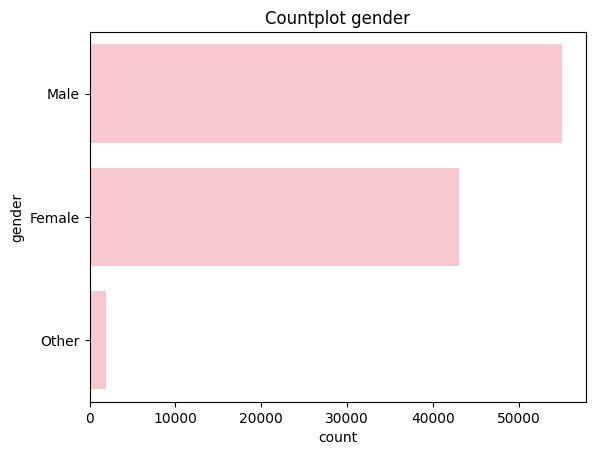

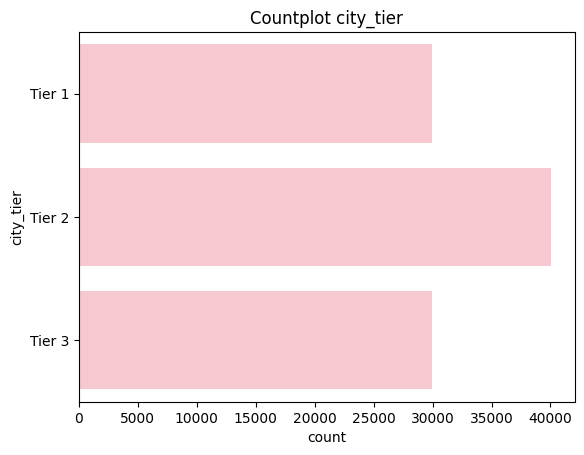

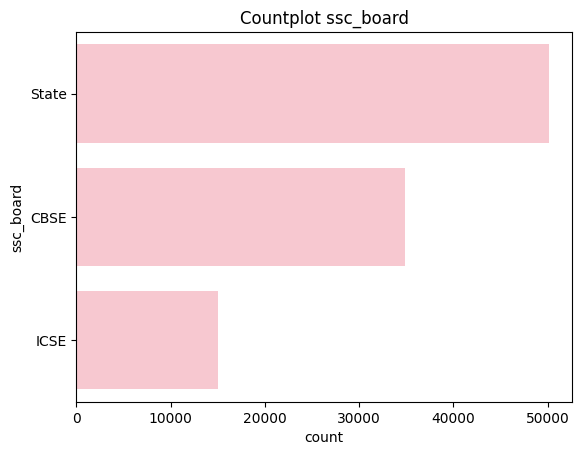

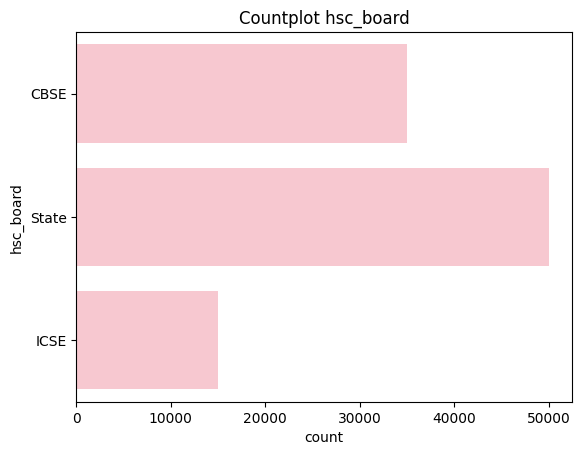

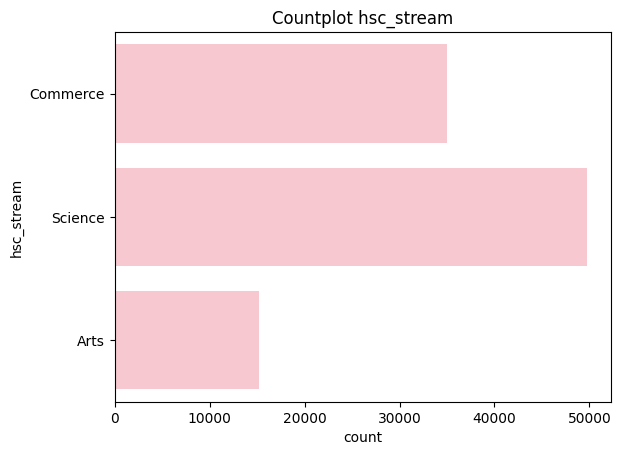

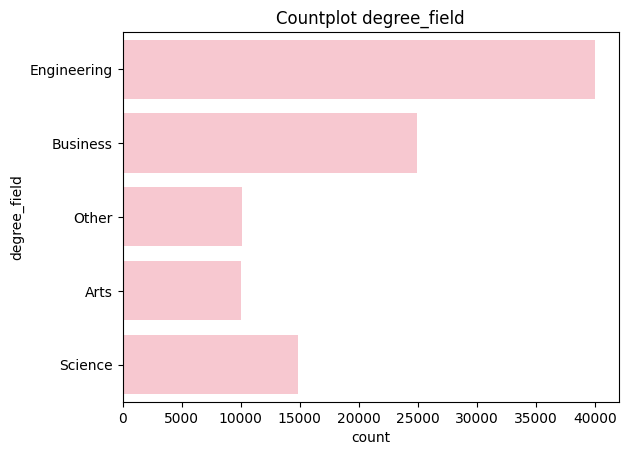

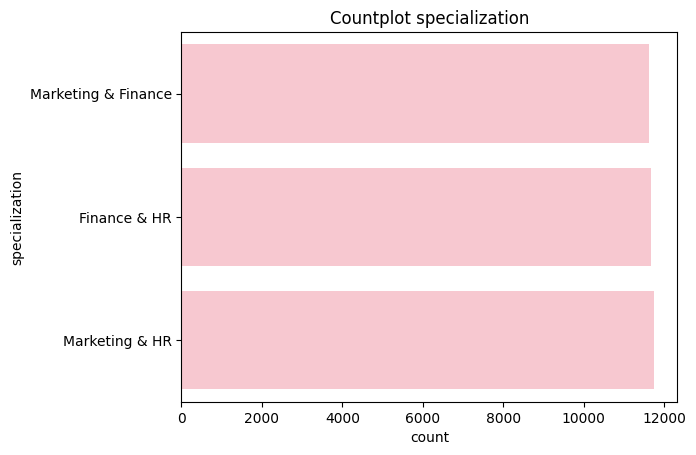

In [ ]:
def cat_countplot(df):
  cat_cols=["gender","city_tier","ssc_board","hsc_board","hsc_stream","degree_field","specialization"]
  for col in cat_cols:
    plt.figure()
    sns.countplot(y=col,data=df,color="pink")
    plt.title(f"Countplot {col}")
    plt.show()
cat_countplot(df)

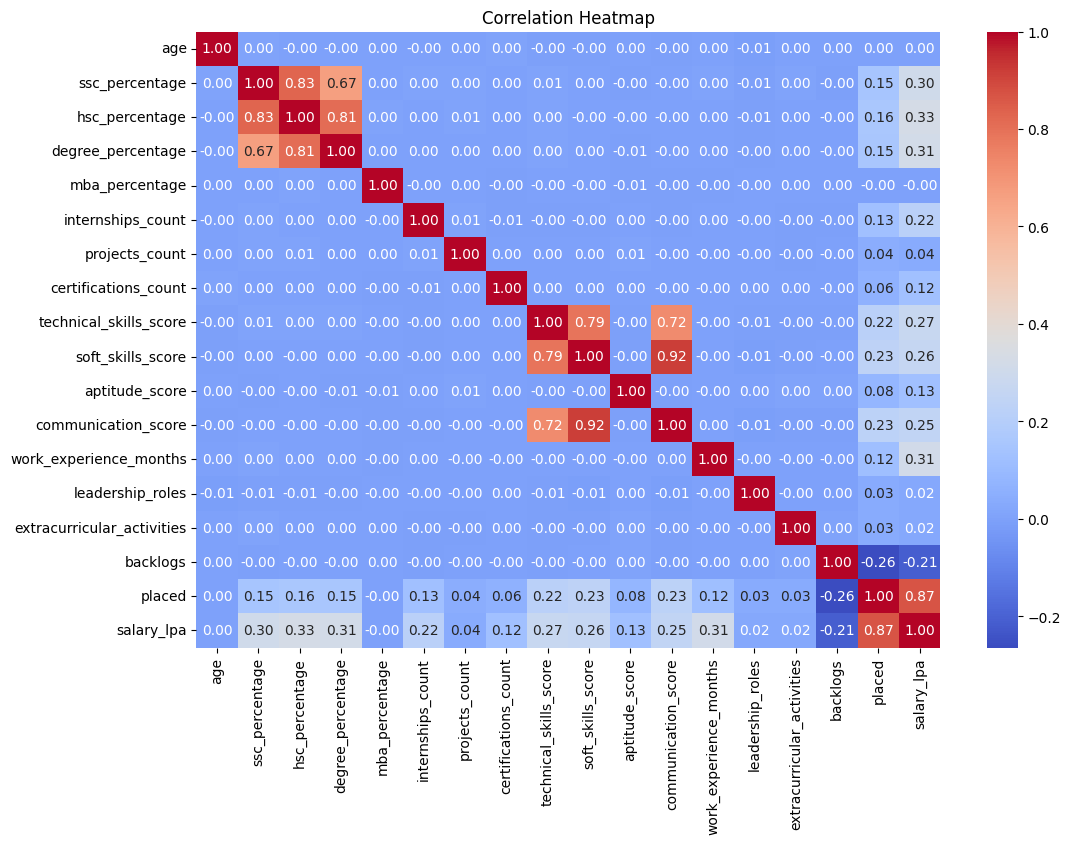

In [ ]:
def correlation_analysis(df):
  plt.figure(figsize=(12,8))
  corr=df.corr(numeric_only=True)
  sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
  plt.title("Correlation Heatmap")
  plt.show()
correlation_analysis(df)

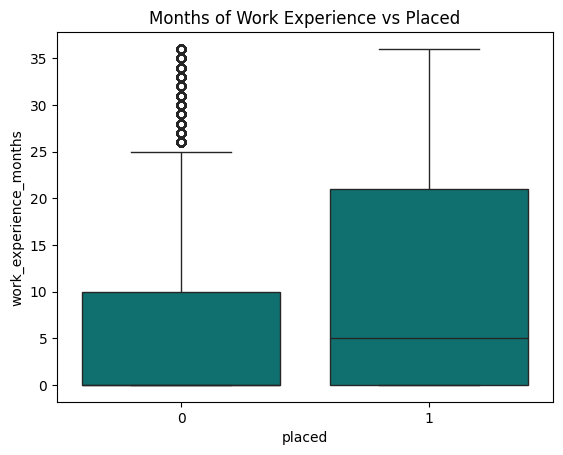

In [ ]:
def work_ex_vs_placed_boxplot(df):
  plt.figure()
  sns.boxplot(x="placed",y="work_experience_months",data=df,color="teal")
  plt.title(f"Months of Work Experience vs Placed")
work_ex_vs_placed_boxplot(df)

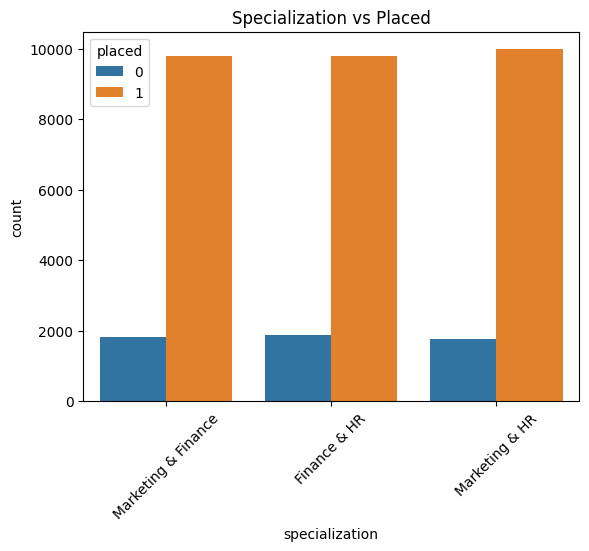

In [ ]:
def special_vs_placed_countplot(df):
  plt.figure()
  sns.countplot(x="specialization",hue="placed",data=df)
  plt.xticks(rotation=45)
  plt.title(f"Specialization vs Placed")
  plt.show()
special_vs_placed_countplot(df)

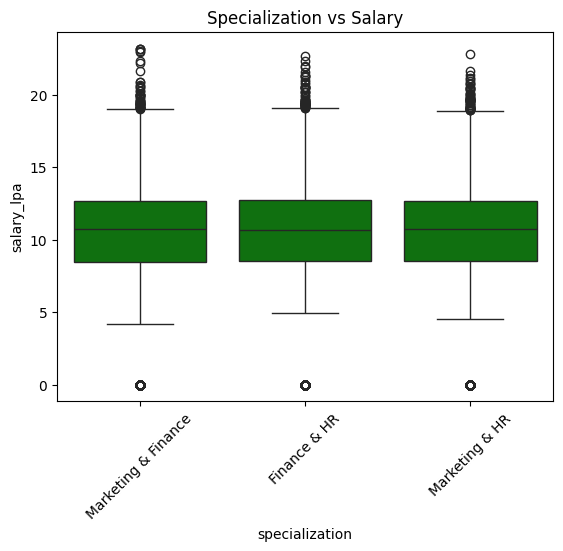

In [ ]:
def special_vs_salary_boxplot(df):
  plt.figure()
  sns.boxplot(x="specialization",y="salary_lpa",data=df,color="green")
  plt.xticks(rotation=45)
  plt.title(f"Specialization vs Salary")
  plt.show()
special_vs_salary_boxplot(df)

# Feature Engineering

In [ ]:
# Dropping cols student_id as it is irrelevant and unhelpful
df=df.drop(columns=["student_id"],axis=1)

In [ ]:
# Dropping mba_percentage, specialization and age as they have 0 correlation with the targets
uncorrelated_cols=["mba_percentage","specialization","age"]
df=df.drop(columns=uncorrelated_cols,axis=1)

In [ ]:
# Dropping communication_score and ssc_percentage as they have very high correlations with soft_skills_score and hsc_percentage respectively,
# causing multicollinearity in the data.
multicollinear_cols=["communication_score","ssc_percentage"]
df=df.drop(columns=multicollinear_cols,axis=1)

In [ ]:
# Combining hsc_percentage and degree_percentage as they have high correlation, but both have high correlation with the target
# Combining technical_skills_score and soft_skills_score as they have high correlation, but both have high correlation with the target
df["skills_score"]=(df["technical_skills_score"]+df["soft_skills_score"])/2
df=df.drop(columns=["technical_skills_score","soft_skills_score"],axis=1)
df["academic_percentage"]=(df["hsc_percentage"]+df["degree_percentage"])/2
df=df.drop(columns=["hsc_percentage","degree_percentage"],axis=1)

# Label Encoding for categorical columns

In [ ]:
board={
    "State": 1,
    "CBSE": 2,
    "ICSE": 3
}
city={
    "Tier 1": 1,
    "Tier 2": 2,
    "Tier 3": 3
}
stream={
    "Commerce": 2,
    "Science": 1,
    "Arts": 3
}
gender={
    "Male": 2,
    "Female": 1,
    "Other": 3
}
degree={
    "Engineering": 1,
    "Business": 2,
    "Other": 3,
    "Arts": 4,
    "Science": 5
}
df["ssc_board"]=df["ssc_board"].map(board)
df["hsc_board"]=df["hsc_board"].map(board)
df["hsc_stream"]=df["hsc_stream"].map(stream)
df["degree_field"]=df["degree_field"].map(degree)
df["gender"]=df["gender"].map(gender)
df["city_tier"]=df["city_tier"].map(city)

# Train Test Split

In [ ]:
X=df.drop(columns=["placed","salary_lpa"])
y=df["placed"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,stratify=y,random_state=0)

In [ ]:
df_reg=df[df["placed"]==1].copy()
X=df_reg.drop(columns=["placed","salary_lpa"])
y=df_reg["salary_lpa"]
X_train_reg,X_test_reg,y_train_reg,y_test_reg=train_test_split(X,y,test_size=0.3,random_state=0)

# Model training

## Classification

### LightGBM Classifier

In [ ]:
lgbm_model=LGBMClassifier()
lgbm_model.fit(X_train,y_train)
preds=lgbm_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test,preds)}")
print("Classification Report:\n",classification_report(y_test,preds))
print("Confusion matrix:\n",confusion_matrix(y_test,preds))

[LightGBM] [Info] Number of positive: 59102, number of negative: 10898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007221 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 809
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.844314 -> initscore=1.690685
[LightGBM] [Info] Start training from score 1.690685
Accuracy: 0.8583
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.26      0.36      4670
           1       0.88      0.97      0.92     25330

    accuracy                           0.86     30000
   macro avg       0.74      0.61      0.64     30000
weighted avg       0.83      0.86      0.83     30000

Confusion matrix:
 [[ 1200  3470]
 [  781 24549]]


### Random Forest Classifier

In [ ]:
rf_model=RandomForestClassifier(n_estimators=200,random_state=42)
rf_model.fit(X_train,y_train)
preds=rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test,preds)}")
print("Classification Report:\n",classification_report(y_test,preds))
print("Confusion matrix:\n",confusion_matrix(y_test,preds))

Accuracy: 0.8565
Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.20      0.30      4670
           1       0.87      0.98      0.92     25330

    accuracy                           0.86     30000
   macro avg       0.75      0.59      0.61     30000
weighted avg       0.83      0.86      0.82     30000

Confusion matrix:
 [[  922  3748]
 [  557 24773]]


### Gradient Boosting Classifier

In [ ]:
gb_model=GradientBoostingClassifier()
gb_model.fit(X_train,y_train)
preds=gb_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test,preds)}")
print("Classification Report:\n",classification_report(y_test,preds))
print("Confusion matrix:\n",confusion_matrix(y_test,preds))

Accuracy: 0.8585
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.22      0.33      4670
           1       0.87      0.98      0.92     25330

    accuracy                           0.86     30000
   macro avg       0.75      0.60      0.63     30000
weighted avg       0.83      0.86      0.83     30000

Confusion matrix:
 [[ 1043  3627]
 [  618 24712]]


### XGBoost Classifier

In [ ]:
xgb_model=XGBClassifier(
n_estimators=600,
max_depth=6,
learning_rate=0.03,
subsample=0.8,
colsample_bytree=0.8,
random_state=0,
eval_metric="logloss",
use_label_encoder=False
)
xgb_model.fit(X_train,y_train)
preds=xgb_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test,preds)}")
print("Classification Report:\n",classification_report(y_test,preds))
print("Confusion matrix:\n",confusion_matrix(y_test,preds))

Accuracy: 0.8572333333333333
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.26      0.36      4670
           1       0.88      0.97      0.92     25330

    accuracy                           0.86     30000
   macro avg       0.74      0.61      0.64     30000
weighted avg       0.83      0.86      0.83     30000

Confusion matrix:
 [[ 1227  3443]
 [  840 24490]]


## Regression

### Linear Regression

In [ ]:
lr_model=LinearRegression()
lr_model.fit(X_train_reg,y_train_reg)
preds=lr_model.predict(X_test_reg)
print(f"MAE: {mean_absolute_error(y_test_reg,preds)}")
print(f"RMSE: {mean_squared_error(y_test_reg,preds)}")
print(f"R2: {r2_score(y_test_reg,preds)}")

MAE: 0.9732884840022318
RMSE: 1.3879880192241019
R2: 0.7873535832399413


### Random Forest Regressor

In [ ]:
rf_reg_model=RandomForestRegressor(n_estimators=200,random_state=42)
rf_reg_model.fit(X_train_reg,y_train_reg)
preds=rf_reg_model.predict(X_test_reg)
print(f"MAE: {mean_absolute_error(y_test_reg,preds)}")
print(f"RMSE: {mean_squared_error(y_test_reg,preds)}")
print(f"R2: {r2_score(y_test_reg,preds)}")

MAE: 0.9534150927753652
RMSE: 1.3477375034320962
R2: 0.7935201551680613


### Gradient Boosting Regressor

In [ ]:
gb_reg_model=GradientBoostingRegressor()
gb_reg_model.fit(X_train_reg,y_train_reg)
preds=gb_reg_model.predict(X_test_reg)
print(f"MAE: {mean_absolute_error(y_test_reg,preds)}")
print(f"RMSE: {mean_squared_error(y_test_reg,preds)}")
print(f"R2: {r2_score(y_test_reg,preds)}")

MAE: 0.923858792742702
RMSE: 1.23989822071135
R2: 0.8100416501225787


### XGBoost Regressor

In [ ]:
xgb_reg=XGBRegressor(
n_estimators=600,
max_depth=6,
learning_rate=0.03,
colsample_bytree=0.8,
random_state=0,
objective="reg:squarederror"
)
xgb_reg.fit(X_train_reg,y_train_reg)
preds=xgb_reg.predict(X_test_reg)
print(f"MAE: {mean_absolute_error(y_test_reg,preds)}")
print(f"RMSE: {mean_squared_error(y_test_reg,preds)}")
print(f"R2: {r2_score(y_test_reg,preds)}")

MAE: 0.9062019183320392
RMSE: 1.1766904147042092
R2: 0.8197253889391407


# K-Fold Cross Validation

In [ ]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=0)
scores=cross_val_score(gb_model,X_train,y_train,cv=cv,scoring="f1_macro")
print(f"CV Macro F1:{scores.mean():.4f}")

CV Macro F1:0.6289


In [ ]:
cv=KFold(n_splits=5,shuffle=True,random_state=0)
scores=cross_val_score(xgb_reg,X_train_reg,y_train_reg,cv=cv,scoring="neg_mean_squared_error")
print(f"CV MSE:{scores.mean():.4f}")

CV MSE:-1.1652


# Statistical Testing

## Classification

### Confidence Intervals

In [ ]:
preds=gb_model.predict(X_test)
acc=accuracy_score(y_test,preds)
n=len(y_test)
se=np.sqrt((acc*(1-acc))/n)
lower=acc-1.96*se
upper=acc+1.96*se
print(f"Accuracy: {acc:.4f}")
print(f"95% CI: [{lower:.4f}, {upper:.4f}]")

Accuracy: 0.8585
95% CI: [0.8546, 0.8624]


Interpretation:   
The model achieves an accuracy of 85.85% on the test set. Given the large sample size, the 95% confidence interval is narrow [85.46%, 86.24%], indicating that the performance estimate is statistically stable and unlikely to be due to random sampling variation.
However, since the dataset is imbalanced (≈85% of students are placed), a naïve classifier that always predicts “placed” would achieve approximately 84–85% accuracy. Therefore, while the model outperforms the baseline, accuracy alone is not a sufficient performance metric in this context.

### ROC AUC + PR AUC

In [ ]:
y_proba=gb_model.predict_proba(X_test)[:,1]
roc_auc=roc_auc_score(y_test,y_proba)
pr_auc=average_precision_score(y_test,y_proba)
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

ROC AUC: 0.8333
PR AUC: 0.9588


Interpretation:   
The ROC AUC of 0.8333 indicates good discriminative ability. Specifically, there is an 83.33% probability that the model assigns a higher predicted probability to a randomly selected placed student than to a randomly selected not placed student.
This suggests that the model is able to meaningfully separate the two classes and provides a strong ranking capability independent of any specific decision threshold.    
The Precision-Recall AUC is 0.9588, which indicates strong performance in maintaining high precision across varying recall levels.
However, because the positive class (placed) constitutes approximately 85% of the dataset, PR AUC is naturally elevated due to class imbalance. Therefore, this metric should be interpreted in conjunction with ROC AUC rather than in isolation.
Despite the imbalance, the high PR AUC confirms that the model maintains strong precision when identifying placed students.

### Brier Score (Calibration Quality)

In [ ]:
brier=brier_score_loss(y_test,y_proba)
print(f"Brier Score: {brier:.4f}")

Brier Score: 0.1017


Interpretation:       
The Brier Score measures the mean squared difference between predicted probabilities and actual outcomes. A value of 0.1017 indicates reasonably well-calibrated probability estimates. Given the class imbalance, a naïve probability predictor assigning the base rate (~0.85) would yield a Brier score of approximately:
p(1−p)≈0.85×0.15=0.1275     
Since 0.1017 < 0.1275, the model improves upon the baseline and produces informative probability estimates suitable for threshold optimization and decision-based applications.

## Regression

### Residual Diagnostics (Visual Bias Detection)

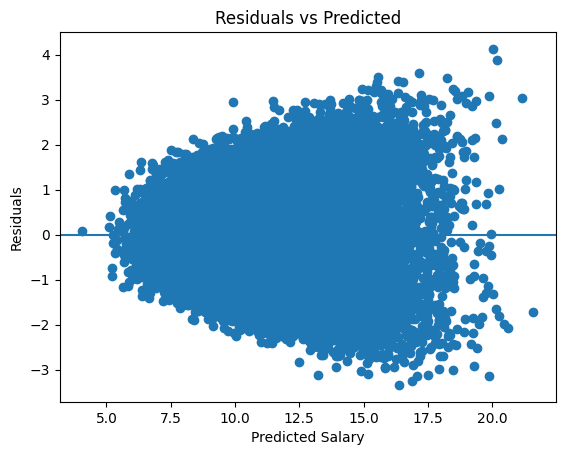

In [ ]:
preds=xgb_reg.predict(X_test_reg)
residuals=y_test_reg-preds
plt.scatter(preds,residuals)
plt.axhline(0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

Interpretation:   
The residuals vs predicted salary plot shows that while residuals are generally centered around zero (indicating no strong systematic bias), their spread increases as predicted salary increases. This widening pattern confirms the presence of heteroscedasticity, meaning the variance of errors is not constant across salary levels. In practical terms, the model is reasonably accurate overall but less precise for higher salary predictions, suggesting that uncertainty grows in the upper salary range and variance-aware modeling approaches could further improve reliability.

### Breusch–Pagan Test (Heteroscedasticity)

In [ ]:
X_with_const=sm.add_constant(preds)
bp_test=het_breuschpagan(residuals,X_with_const)
labels=["LM Stat","LM p-value","F Stat","F p-value"]
print(dict(zip(labels,bp_test)))

{'LM Stat': np.float64(2760.8628342042507), 'LM p-value': np.float64(0.0), 'F Stat': np.float64(3098.352114705656), 'F p-value': np.float64(0.0)}


Interpretation:     
The Breusch-Pagan test strongly rejects the null hypothesis of homoscedasticity (constant variance of residuals), with p-value ≈ 0.
This indicates the presence of heteroscedasticity, meaning that prediction errors vary systematically with the level of predicted salary. In practical terms, the model's prediction uncertainty increases or decreases across salary ranges, which is common in income modeling.   
This suggests that:
* Prediction intervals may not be uniform across the salary distribution.
* Variance-aware modeling (e.g., log transformation or quantile regression) could further improve reliability.

### Bootstrap Confidence Interval for R²

In [ ]:
boot_scores=[]
n=len(y_test_reg)
for _ in range(1000):
  idx=np.random.choice(range(n),n,replace=True)
  boot_scores.append(r2_score(y_test_reg.iloc[idx],preds[idx]))
lower=np.percentile(boot_scores,2.5)
upper=np.percentile(boot_scores,97.5)
print(f"R2: {r2_score(y_test_reg,preds):.4f}")
print(f"95% Bootstrap CI: [{lower:.4f}, {upper:.4f}]")

R2: 0.8197
95% Bootstrap CI: [0.8164, 0.8231]


Interpretation:     
The regression model explains approximately 81.97% of the variance in salary outcomes on the test set.
Bootstrap resampling yields a narrow 95% confidence interval [81.64%, 82.31%], indicating that model performance is stable and not sensitive to sampling variability.
This suggests strong predictive capability and good generalization performance.

## Final Statistical Model Evaluation

The classification model demonstrates statistically stable performance with good discriminative ability (ROC AUC = 0.8333) and well-calibrated probability estimates (Brier Score = 0.1017). However, due to significant class imbalance, accuracy alone overstates performance gains relative to a naïve baseline.     
The regression model shows strong explanatory power (R² ≈ 0.82) with stable performance under bootstrap resampling. Nevertheless, residual diagnostics reveal significant heteroscedasticity, indicating non-constant error variance across salary levels.

# SHAP - Explainability

## Classification Model Explainability

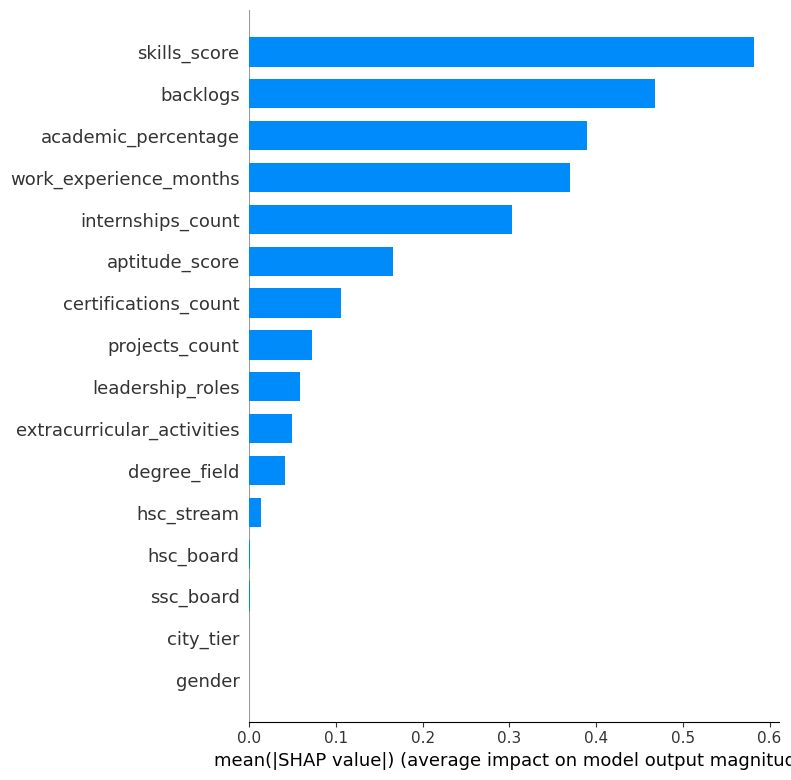

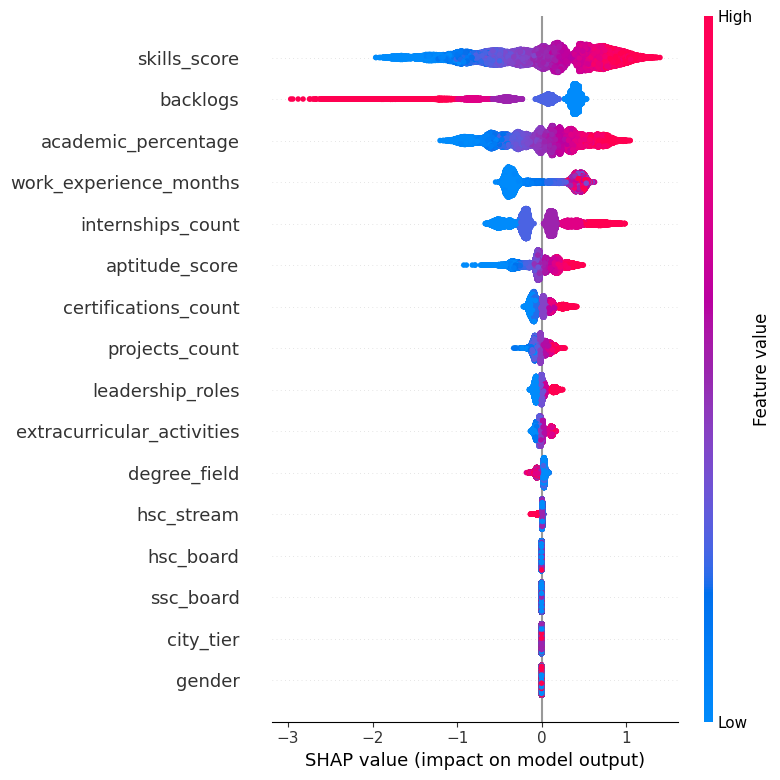

In [ ]:
explainer=shap.TreeExplainer(gb_model)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test,plot_type="bar")
shap.summary_plot(shap_values,X_test)

Interpretation:     
The SHAP plots show that skills_score is the most influential factor in the model's prediction, followed by backlogs, academic_percentage, work_experience_months, and internships_count, indicating that stronger skills, better academics, more experience, and more internships generally increase the predicted outcome, while higher backlogs tend to reduce it. Mid-level factors such as aptitude_score, certifications_count, and projects_count contribute moderately, whereas attributes like leadership_roles and extracurricular_activities have smaller effects. Demographic or background variables such as degree_field, hsc_stream, boards, city_tier, and gender show minimal impact, suggesting the model relies primarily on skill, academic, and experience-related features for its predictions.

## Regression Model Explainability

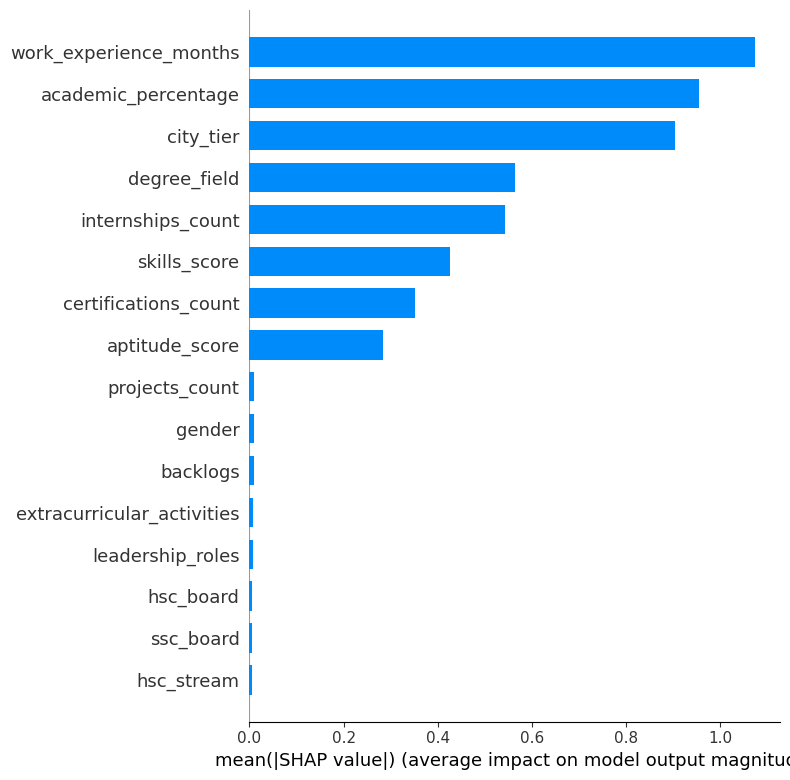

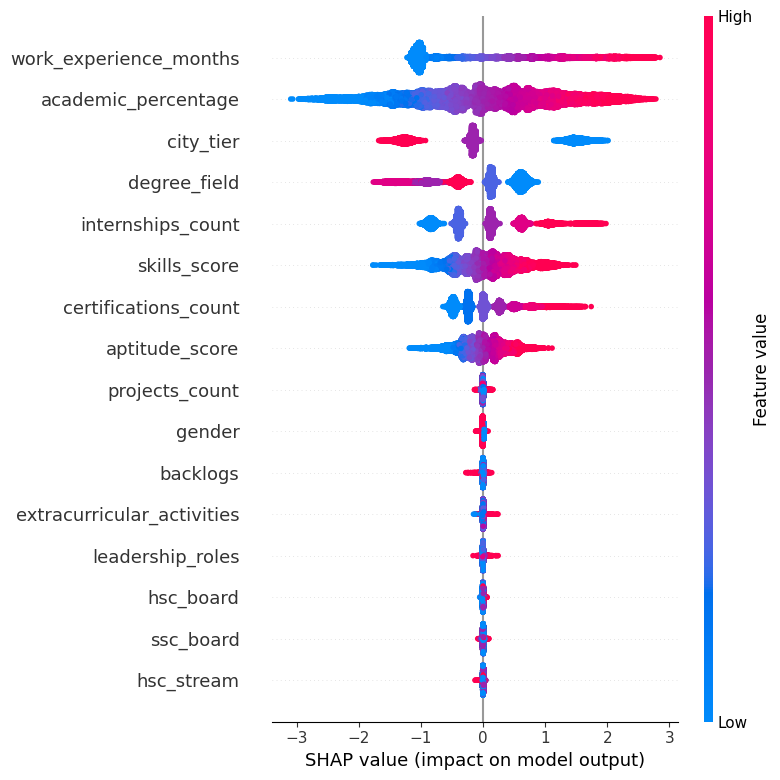

In [ ]:
explainer=shap.TreeExplainer(xgb_reg)
shap_values=explainer.shap_values(X_test_reg)
shap.summary_plot(shap_values,X_test_reg,plot_type="bar")
shap.summary_plot(shap_values,X_test_reg)

Interpretation:       
The SHAP plots indicate that work_experience_months has the strongest influence on the model's predictions, followed by academic_percentage and city_tier, showing that greater work experience, stronger academic performance, and certain city tiers significantly increase the predicted outcome. Degree_field, internships_count, and skills_score also contribute notably, suggesting that educational background, internship exposure, and skill levels play an important role. Features like certifications_count and aptitude_score have moderate influence, while variables such as projects_count, gender, backlogs, extracurricular_activities, leadership_roles, and school-related attributes have minimal impact, indicating the model relies mainly on experience, academics, and location-related factors.

# Saving the best Classification and Regression models

In [ ]:
import pickle

In [ ]:
class_model = 'gradient_boost_model.pkl'
reg_model = 'xg_boost_reg.pkl'

In [ ]:
with open(class_model, 'wb') as file:
  pickle.dump(gb_model, file)
with open(reg_model, 'wb') as file:
  pickle.dump(xgb_reg, file)